# Advanced Residue Importance Analysis (Attention Pooling)

This notebook provides a **robust, MD-aware analysis** of attention pooling weights `w(t, i)` extracted from your Transformer Autoencoder.

## What you get
1. **Sanity checks** (row-sum ≈ 1, shapes, missing files).
2. **Per-residue statistics**: mean/median/std/percentiles/IQR.
3. **MD-robust uncertainty**: **block bootstrap 95% CI** for mean/median.
4. **Interpretability metrics**:
   - **Duty cycle**: how often a residue is "dominant" (above a threshold).
   - **Expected rank**: average rank of each residue per frame.
   - **Cumulative contribution**: how many residues explain 80–95% of mean attention.
5. **State-wise analysis** (requires `latents.npy`): cluster basins and compute per-state residue importance.
6. **Transition analysis** (requires `latents.npy`): detect **entries into rare states** and compute **pre-entry residue importance**.

## Required files in OUTPUT_DIR
- `attn_weights.npy`   (T x N)
- `token_residue_ids.txt` (N)
- `latents.npy` (T x d)  **required for clustering + transitions**


In [8]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- CONFIG ---
OUTPUT_DIR = Path('../test05/output')  # <-- set to your run directory

# For MD autocorrelation: choose a block length in frames for block bootstrap.
# If you're unsure, start with 200–1000 frames depending on your stride.
BLOCK_LEN = 500

# Clustering
CLUSTER_METHOD = 'gmm'   # 'gmm' or 'kmeans'
N_CLUSTERS = 10          # for kmeans/gmm
RANDOM_SEED = 42

# Define rare states by population fraction
RARE_FRACTION_THRESHOLD = 0.05  # clusters with <2% frames are 'rare'

# Transition analysis
PRE_ENTRY_WINDOW = 200   # frames before entering a rare state
REFRACTORY = 200         # minimum frames between consecutive entries into the same rare state

# Dominance threshold for duty cycle
# Default: 2x uniform attention
def dominance_threshold(n_tokens: int) -> float:
    return 2.0 / float(n_tokens)

print('OUTPUT_DIR:', OUTPUT_DIR.resolve())
assert OUTPUT_DIR.exists(), f"OUTPUT_DIR not found: {OUTPUT_DIR}"

OUTPUT_DIR: /home/tedeschg/prj/cvformer/cvformer-test/test05/output


In [9]:
# Load required arrays
W_path = OUTPUT_DIR / 'attn_weights.npy'
resids_path = OUTPUT_DIR / 'token_residue_ids.txt'
Z_path = OUTPUT_DIR / 'latents.npy'

assert W_path.exists(), f"Missing {W_path}"
assert resids_path.exists(), f"Missing {resids_path}"
assert Z_path.exists(), f"Missing {Z_path} (needed for clustering/transitions)"

W = np.load(W_path)  # (T, N)
residue_ids = np.loadtxt(resids_path, dtype=int)  # (N,)
Z = np.load(Z_path)  # (T, d)

print('W:', W.shape)
print('residue_ids:', residue_ids.shape)
print('Z:', Z.shape)
assert W.shape[1] == residue_ids.shape[0], 'Mismatch: W tokens != residue_ids length'
assert W.shape[0] == Z.shape[0], 'Mismatch: W frames != Z frames'

# Sanity: attention weights should sum to ~1 per frame
row_sums = W.sum(axis=1)
print('Row sums min/mean/max:', row_sums.min(), row_sums.mean(), row_sums.max())
print('Mean abs deviation from 1:', float(np.mean(np.abs(row_sums - 1.0))))

# Normalize latents for clustering
Zn = (Z - Z.mean(axis=0, keepdims=True)) / (Z.std(axis=0, keepdims=True) + 1e-12)


W: (10440, 18)
residue_ids: (18,)
Z: (10440, 2)
Row sums min/mean/max: 0.9999998 1.0 1.0000002
Mean abs deviation from 1: 3.31422391752767e-08


In [10]:
# Per-residue statistics (global)
T, N = W.shape
w_mean = W.mean(axis=0)
w_median = np.median(W, axis=0)
w_std = W.std(axis=0)
w_p05 = np.percentile(W, 5, axis=0)
w_p25 = np.percentile(W, 25, axis=0)
w_p75 = np.percentile(W, 75, axis=0)
w_p95 = np.percentile(W, 95, axis=0)
w_iqr = w_p75 - w_p25

df_global = pd.DataFrame({
    'token': np.arange(N),
    'residue_id': residue_ids,
    'mean': w_mean,
    'median': w_median,
    'std': w_std,
    'p05': w_p05,
    'p25': w_p25,
    'p75': w_p75,
    'p95': w_p95,
    'iqr': w_iqr,
})

# Episodic score: highlights rare spikes
df_global['episodic_score'] = df_global['p95'] / (df_global['mean'] + 1e-12)

out_csv = OUTPUT_DIR / 'attn_residue_stats_global.csv'
df_global.to_csv(out_csv, index=False)
print('Saved:', out_csv)

df_global.head()

Saved: ../test05/output/attn_residue_stats_global.csv


,token,residue_id,mean,median,std,p05,p25,p75,p95,iqr,episodic_score
0,0,1,0.058125,0.058157,0.030441,0.014291,0.037388,0.074572,0.106903,0.037185,1.839178
1,1,2,0.053022,0.051766,0.030146,0.008115,0.030208,0.070625,0.105041,0.040417,1.981102
2,2,3,0.053773,0.053199,0.032988,0.004231,0.033194,0.069588,0.108101,0.036394,2.010337
3,3,4,0.048956,0.039266,0.045787,0.000435,0.009545,0.074176,0.129024,0.064631,2.635524
4,4,5,0.028569,0.014614,0.036047,0.000039,0.000891,0.049183,0.093812,0.048291,3.283723


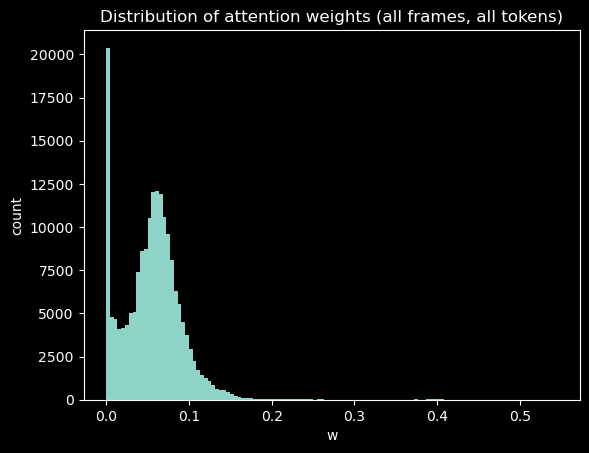

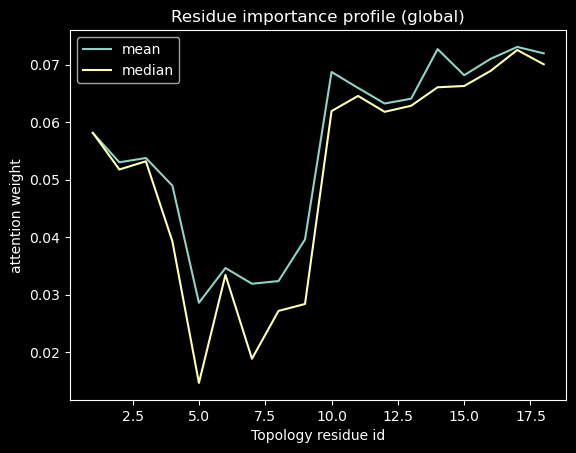

In [11]:
# Plot global distributions
W_flat = W.ravel()
plt.figure()
plt.hist(W_flat, bins=120)
plt.title('Distribution of attention weights (all frames, all tokens)')
plt.xlabel('w')
plt.ylabel('count')
plt.show()

# Profile along sequence (sorted by residue id)
df_sorted = df_global.sort_values('residue_id').reset_index(drop=True)
plt.figure()
plt.plot(df_sorted['residue_id'].values, df_sorted['mean'].values, label='mean')
plt.plot(df_sorted['residue_id'].values, df_sorted['median'].values, label='median')
plt.title('Residue importance profile (global)')
plt.xlabel('Topology residue id')
plt.ylabel('attention weight')
plt.legend()
plt.show()

In [12]:
# Duty cycle (dominance frequency) and expected rank
thr = dominance_threshold(N)

# Duty cycle: fraction of frames where w(t,i) exceeds threshold
duty = (W > thr).mean(axis=0)

# Expected rank: average rank per frame (1 = highest attention)
order = np.argsort(-W, axis=1)  # (T, N) tokens sorted by descending w
ranks = np.empty_like(order)
rows = np.arange(T)[:, None]
ranks[rows, order] = np.arange(N)[None, :]
expected_rank = ranks.mean(axis=0) + 1.0

df_global['duty_cycle'] = duty
df_global['expected_rank'] = expected_rank

out_csv2 = OUTPUT_DIR / 'attn_residue_stats_global_plus.csv'
df_global.to_csv(out_csv2, index=False)
print('Saved:', out_csv2)

print('Dominance threshold used:', thr)
df_global.sort_values('mean', ascending=False).head(10)[['residue_id','mean','median','p95','episodic_score','duty_cycle','expected_rank']]

Saved: ../test05/output/attn_residue_stats_global_plus.csv
Dominance threshold used: 0.1111111111111111


,residue_id,mean,median,p95,episodic_score,duty_cycle,expected_rank
16,17,0.073108,0.072572,0.111630,1.526914,0.051149,6.552874
13,14,0.072730,0.066082,0.144504,1.986852,0.178831,7.725670
17,18,0.071992,0.070082,0.113571,1.577553,0.056418,6.868678
15,16,0.071039,0.068942,0.109186,1.536994,0.044349,6.673372
9,10,0.068749,0.061933,0.119777,1.742229,0.067720,8.156513
14,15,0.068182,0.066307,0.108036,1.584523,0.042433,7.234866
10,11,0.065965,0.064577,0.110797,1.679617,0.049042,7.491667
12,13,0.064093,0.062861,0.105485,1.645823,0.032950,8.122318
11,12,0.063257,0.061810,0.107366,1.697304,0.037739,8.318391
0,1,0.058125,0.058157,0.106903,1.839178,0.041092,8.903065


Residues to explain 80% of mean attention: 13 / 18
Residues to explain 90% of mean attention: 15 / 18
Residues to explain 95% of mean attention: 17 / 18
Residues to explain 99% of mean attention: 18 / 18


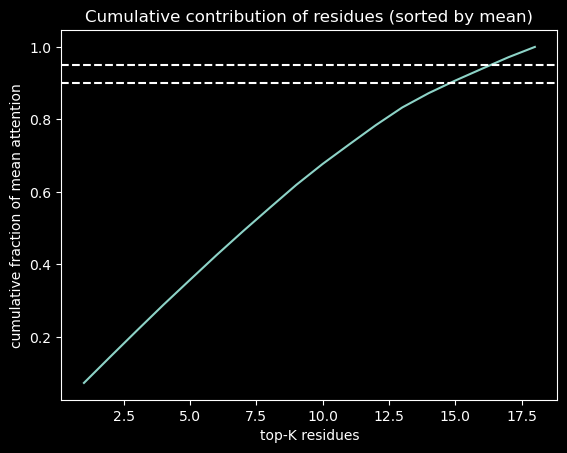

In [13]:
# Cumulative contribution: how many residues explain X% of mean attention
m = df_global[['token','residue_id','mean']].sort_values('mean', ascending=False).reset_index(drop=True)
cum = np.cumsum(m['mean'].values)
total = cum[-1]

def n_for_frac(frac: float) -> int:
    return int(np.searchsorted(cum, frac * total) + 1)

for frac in [0.80, 0.90, 0.95, 0.99]:
    print(f"Residues to explain {int(frac*100)}% of mean attention: {n_for_frac(frac)} / {N}")

plt.figure()
plt.plot(np.arange(1, N+1), cum / total)
plt.axhline(0.9, linestyle='--')
plt.axhline(0.95, linestyle='--')
plt.title('Cumulative contribution of residues (sorted by mean)')
plt.xlabel('top-K residues')
plt.ylabel('cumulative fraction of mean attention')
plt.show()

In [14]:
# Block bootstrap 95% CI for mean and median (MD-aware)
rng = np.random.default_rng(RANDOM_SEED)

def block_bootstrap_ci(W: np.ndarray, block_len: int, n_boot: int = 300, stat: str = 'mean'):
    T, N = W.shape
    block_len = int(max(1, block_len))
    n_blocks = int(np.ceil(T / block_len))
    starts = np.arange(0, T, block_len)

    boots = np.empty((n_boot, N), dtype=np.float64)
    for b in range(n_boot):
        pick = rng.integers(0, len(starts), size=n_blocks)
        idx = []
        for p in pick:
            s = int(starts[p])
            e = min(T, s + block_len)
            idx.append(np.arange(s, e))
        idx = np.concatenate(idx)[:T]
        X = W[idx]
        if stat == 'mean':
            boots[b] = X.mean(axis=0)
        elif stat == 'median':
            boots[b] = np.median(X, axis=0)
        else:
            raise ValueError('stat must be mean or median')

    lo = np.percentile(boots, 2.5, axis=0)
    hi = np.percentile(boots, 97.5, axis=0)
    return lo, hi

CI_BOOT = 300
mean_lo, mean_hi = block_bootstrap_ci(W, BLOCK_LEN, n_boot=CI_BOOT, stat='mean')
med_lo, med_hi = block_bootstrap_ci(W, BLOCK_LEN, n_boot=CI_BOOT, stat='median')

df_global['mean_ci_lo'] = mean_lo
df_global['mean_ci_hi'] = mean_hi
df_global['median_ci_lo'] = med_lo
df_global['median_ci_hi'] = med_hi

out_ci = OUTPUT_DIR / 'attn_residue_stats_global_with_ci.csv'
df_global.to_csv(out_ci, index=False)
print('Saved:', out_ci)

df_global.sort_values('mean', ascending=False).head(10)[['residue_id','mean','mean_ci_lo','mean_ci_hi','median','median_ci_lo','median_ci_hi','duty_cycle','expected_rank']]

Saved: ../test05/output/attn_residue_stats_global_with_ci.csv


,residue_id,mean,mean_ci_lo,mean_ci_hi,median,median_ci_lo,median_ci_hi,duty_cycle,expected_rank
16,17,0.073108,0.072415,0.073875,0.072572,0.071126,0.073889,0.051149,6.552874
13,14,0.072730,0.066891,0.078046,0.066082,0.063366,0.069703,0.178831,7.725670
17,18,0.071992,0.071167,0.072809,0.070082,0.069167,0.071200,0.056418,6.868678
15,16,0.071039,0.070495,0.071634,0.068942,0.068380,0.069676,0.044349,6.673372
9,10,0.068749,0.067135,0.070407,0.061933,0.058432,0.064654,0.067720,8.156513
14,15,0.068182,0.067498,0.069032,0.066307,0.065117,0.067542,0.042433,7.234866
10,11,0.065965,0.064137,0.067742,0.064577,0.062562,0.066684,0.049042,7.491667
12,13,0.064093,0.062519,0.065739,0.062861,0.059765,0.065034,0.032950,8.122318
11,12,0.063257,0.061606,0.064978,0.061810,0.059866,0.063692,0.037739,8.318391
0,1,0.058125,0.055944,0.060582,0.058157,0.056044,0.060261,0.041092,8.903065


State populations:


,state,count,fraction
0,9,3861,0.369828
1,4,1856,0.177778
2,0,1124,0.107663
3,5,1035,0.099138
4,1,987,0.094540
5,2,403,0.038602
6,7,379,0.036303
7,6,323,0.030939
8,3,301,0.028831
9,8,171,0.016379


Rare states (<5.00%): [2, 3, 6, 7, 8]


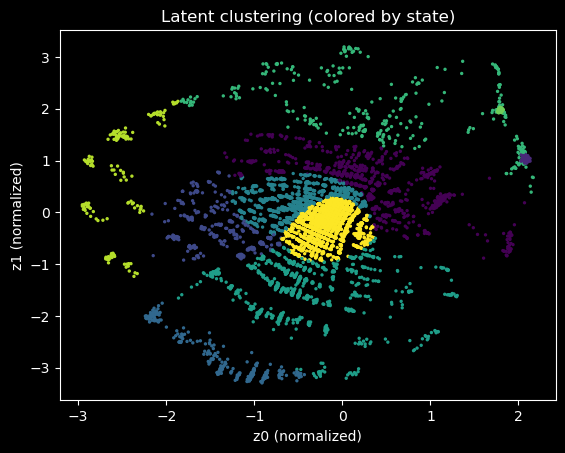

In [15]:
# Clustering in latent space (states)
try:
    from sklearn.mixture import GaussianMixture
    from sklearn.cluster import KMeans
except Exception as e:
    raise ImportError(
        "scikit-learn is required for clustering (pip install scikit-learn). "
        f"Original error: {e}"
    )

if CLUSTER_METHOD.lower() == 'gmm':
    model = GaussianMixture(n_components=N_CLUSTERS, random_state=RANDOM_SEED, covariance_type='full')
    labels = model.fit_predict(Zn)
elif CLUSTER_METHOD.lower() == 'kmeans':
    model = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_SEED, n_init='auto')
    labels = model.fit_predict(Zn)
else:
    raise ValueError("CLUSTER_METHOD must be 'gmm' or 'kmeans'")

labels = labels.astype(int)
pop = np.bincount(labels, minlength=N_CLUSTERS)
pop_frac = pop / pop.sum()

state_df = pd.DataFrame({'state': np.arange(N_CLUSTERS), 'count': pop, 'fraction': pop_frac})
state_df = state_df.sort_values('fraction', ascending=False).reset_index(drop=True)

rare_states = set(np.where(pop_frac < RARE_FRACTION_THRESHOLD)[0].tolist())
print('State populations:')
display(state_df)
print('Rare states (<{:.2%}):'.format(RARE_FRACTION_THRESHOLD), sorted(list(rare_states)))

plt.figure()
if Zn.shape[1] >= 2:
    plt.scatter(Zn[:,0], Zn[:,1], s=2, c=labels)
    plt.title('Latent clustering (colored by state)')
    plt.xlabel('z0 (normalized)')
    plt.ylabel('z1 (normalized)')
    plt.savefig("gmm_clusters.png", dpi=600, bbox_inches="tight", facecolor="white")
    plt.show()
else:
    plt.hist(Zn[:,0], bins=200)
    plt.title('Latent distribution (1D)')

    plt.show()

In [16]:
# State-wise residue importance
state_means = np.zeros((N_CLUSTERS, N), dtype=np.float64)
counts = np.zeros(N_CLUSTERS, dtype=int)
for k in range(N_CLUSTERS):
    idx = np.where(labels == k)[0]
    counts[k] = idx.size
    if idx.size > 0:
        state_means[k] = W[idx].mean(axis=0)
    else:
        state_means[k] = np.nan

np.save(OUTPUT_DIR / 'attn_state_means.npy', state_means)

state_info = pd.DataFrame({'state': np.arange(N_CLUSTERS), 'count': counts, 'fraction': counts / float(T)})
display(state_info.sort_values('fraction', ascending=False))

STATE_TO_INSPECT = int(state_info.sort_values('fraction', ascending=False).iloc[0]['state'])
delta = state_means[STATE_TO_INSPECT] - w_mean

df_delta = pd.DataFrame({
    'token': np.arange(N),
    'residue_id': residue_ids,
    'delta_mean': delta,
    'state_mean': state_means[STATE_TO_INSPECT],
    'global_mean': w_mean,
})

print('Inspecting state:', STATE_TO_INSPECT)
display(df_delta.sort_values('delta_mean', ascending=False).head(20))

,state,count,fraction
9,9,3861,0.369828
4,4,1856,0.177778
0,0,1124,0.107663
5,5,1035,0.099138
1,1,987,0.094540
2,2,403,0.038602
7,7,379,0.036303
6,6,323,0.030939
3,3,301,0.028831
8,8,171,0.016379


Inspecting state: 9


,token,residue_id,delta_mean,state_mean,global_mean
7,7,8,0.022149,0.054494,0.032345
1,1,2,0.011655,0.064677,0.053022
0,0,1,0.010951,0.069076,0.058125
6,6,7,0.008004,0.039882,0.031878
10,10,11,0.007653,0.073619,0.065965
9,9,10,0.004814,0.073563,0.068749
2,2,3,0.002287,0.056060,0.053773
12,12,13,0.002213,0.066306,0.064093
14,14,15,0.001059,0.069241,0.068182
11,11,12,-0.001432,0.061825,0.063257


In [17]:
# Transition analysis: entries into rare states
def find_entries(labels: np.ndarray, target_state: int, refractory: int = 0):
    entries = []
    last = -10**18
    for t in range(1, len(labels)):
        if labels[t] == target_state and labels[t-1] != target_state:
            if t - last >= refractory:
                entries.append(t)
                last = t
    return entries

entries_summary = []
for rs in sorted(list(rare_states)):
    ent = find_entries(labels, rs, refractory=REFRACTORY)
    entries_summary.append({'rare_state': rs, 'n_entries': len(ent)})

entries_df = pd.DataFrame(entries_summary).sort_values('n_entries', ascending=False)
display(entries_df)
print('PRE_ENTRY_WINDOW:', PRE_ENTRY_WINDOW, '| REFRACTORY:', REFRACTORY)

,rare_state,n_entries
2,6,43
0,2,41
1,3,38
4,8,34
3,7,13


PRE_ENTRY_WINDOW: 200 | REFRACTORY: 200


In [18]:
# Pre-entry residue importance for each rare state
def pre_entry_stats_for_state(r: int):
    entries = find_entries(labels, r, refractory=REFRACTORY)
    valid_entries = [t for t in entries if t - PRE_ENTRY_WINDOW >= 0]
    if len(valid_entries) == 0:
        return None

    pre_idx = []
    for t in valid_entries:
        pre_idx.append(np.arange(t - PRE_ENTRY_WINDOW, t))
    pre_idx = np.concatenate(pre_idx)

    base_idx = np.where(labels != r)[0]

    W_pre = W[pre_idx]
    W_base = W[base_idx]

    pre_mean = W_pre.mean(axis=0)
    base_mean = W_base.mean(axis=0)
    delta = pre_mean - base_mean

    return {
        'state': r,
        'n_entries': len(valid_entries),
        'pre_frames': int(W_pre.shape[0]),
        'baseline_frames': int(W_base.shape[0]),
        'pre_mean': pre_mean,
        'baseline_mean': base_mean,
        'delta': delta,
    }

results = []
for r in sorted(list(rare_states)):
    out = pre_entry_stats_for_state(r)
    if out is not None:
        results.append(out)

print('Rare states with valid pre-entry windows:', [x['state'] for x in results])

Rare states with valid pre-entry windows: [2, 3, 6, 7, 8]


In [19]:
# Save top residues by pre-entry delta for each rare state
rows = []
for out in results:
    r = out['state']
    delta = out['delta']
    pre_mean = out['pre_mean']
    base_mean = out['baseline_mean']
    top_idx = np.argsort(-delta)[:30]
    for i in top_idx:
        rows.append({
            'rare_state': r,
            'n_entries': out['n_entries'],
            'token': int(i),
            'residue_id': int(residue_ids[i]),
            'delta_pre_minus_baseline': float(delta[i]),
            'pre_mean': float(pre_mean[i]),
            'baseline_mean': float(base_mean[i]),
        })

pre_df = pd.DataFrame(rows)
out_pre = OUTPUT_DIR / 'attn_pre_entry_top_residues.csv'
pre_df.to_csv(out_pre, index=False)
print('Saved:', out_pre)

if len(results) > 0:
    best = max(results, key=lambda x: x['n_entries'])
    r = best['state']
    print('Example rare state:', r, 'n_entries:', best['n_entries'])
    display(pre_df[pre_df['rare_state'] == r].sort_values('delta_pre_minus_baseline', ascending=False).head(20))
else:
    print('No valid rare-state entries found with current PRE_ENTRY_WINDOW/REFRACTORY.')

Saved: ../test05/output/attn_pre_entry_top_residues.csv
Example rare state: 6 n_entries: 42


,rare_state,n_entries,token,residue_id,delta_pre_minus_baseline,pre_mean,baseline_mean
36,6,42,0,1,1.208235e-03,0.059101,0.057893
37,6,42,1,2,1.116727e-03,0.053883,0.052766
38,6,42,6,7,9.618066e-04,0.033100,0.032139
39,6,42,7,8,5.563386e-04,0.033849,0.033292
40,6,42,2,3,5.128831e-04,0.054507,0.053995
41,6,42,10,11,1.422539e-04,0.066581,0.066439
42,6,42,11,12,3.913045e-05,0.063046,0.063007
43,6,42,5,6,4.395843e-07,0.034936,0.034936
44,6,42,15,16,-1.568794e-04,0.070456,0.070613
45,6,42,12,13,-1.787394e-04,0.063922,0.064101


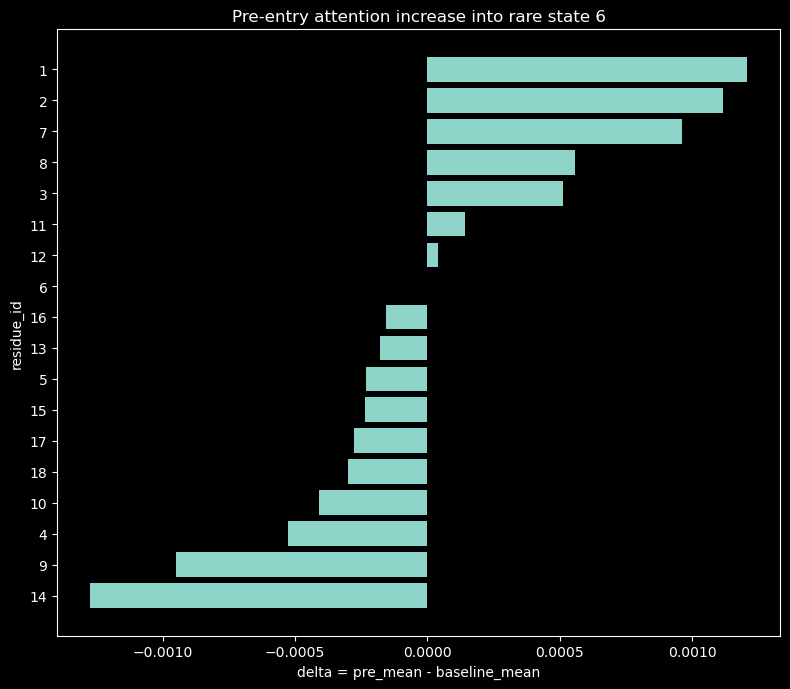

In [20]:
# Plot pre-entry delta for the rare state with most entries
if len(results) > 0:
    RARE_TO_PLOT = max(results, key=lambda x: x['n_entries'])['state']
    sel = [x for x in results if x['state'] == RARE_TO_PLOT][0]
    delta = sel['delta']

    top = np.argsort(-delta)[:25]
    labels_res = [str(int(residue_ids[i])) for i in top][::-1]
    values = delta[top][::-1]

    plt.figure(figsize=(8, 7))
    plt.barh(labels_res, values)
    plt.title(f'Pre-entry attention increase into rare state {RARE_TO_PLOT}')
    plt.xlabel('delta = pre_mean - baseline_mean')
    plt.ylabel('residue_id')
    plt.tight_layout()
    plt.show()
else:
    print('No rare-state transition plot available.')

## Notes

- **Global mean/median**: residues important overall.
- **p95 / episodic_score**: residues that spike in specific events.
- **Duty cycle**: how frequently a residue is above a dominance threshold.
- **Expected rank**: how often it appears near the top of the attention ordering.
- **State-wise delta**: residues that characterize a basin.
- **Pre-entry delta**: residues that become important *before* entering a rare basin (transition candidates).
